#**This Notebook is for Feature Importance Analysis discussed in Section VI.**
Feature interaction analysis with SHAPley.

In [ ]:
from google.colab import drive
drive.mount('/content/drive/', force_remount=True)

Mounted at /content/drive/


In [ ]:
import numpy as np
import pandas as pd
import joblib
import os
import sys
import shap
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
path = '/content/drive/My Drive/CS5228-14ANCHovYs/'
os.chdir(path)
src_path = path + 'src/'
sys.path.append(src_path)
models_path = path + 'models'
intermediate_csv_path = path + 'intermediate_csvs/'


In [ ]:
# Load the validation dataset
sqm_val_df = pd.read_csv(intermediate_csv_path + "sqm_val.csv")

# Extract the features selected
proposed_features2 = ['MONTH_SIN1', 'MONTH_COS1', 'RESALE_QUARTER_RPI', 'RENTAL_PER_SQM', 'REMAINING_LEASE',
                     'TOWN_TE', 'SUBZONE_TE', 'REGION_TE', 'MAX_FLOOR',
                      'NUM_STN_1KM_OPEN', 'NUM_STN_2KM_OPEN',
                       'NUM_MRT_STOPS_1KM_OPEN', 'NUM_MRT_STOPS_2KM_OPEN',
                       'NUM_MRT_INT_1KM_OPEN', 'NUM_MRT_INT_2KM_OPEN',
                      'NUM_MRT_LINES_1KM_OPEN',
                     'NUM_MALL_1KM', 'NUM_MALL_2KM', 'NUM_HAKWER_1KM', 'NUM_HAWKER_2KM',
                     'NUM_PRI_SCH_1KM', 'NUM_PRI_SCH_2KM', 'NUM_SEC_SCH_1KM', 'NUM_SEC_SCH_2KM',
                      'DIST_NEAREST_HAWKER_WALK', 'DIST_NEAREST_MRT_WALK', 'DIST_NEAREST_PRI_SCH_WALK',
                      'DIST_NEAREST_SEC_SCH_WALK', 'DIST_NEAREST_MALL_WALK', 'DIST_TO_CBD', 'DIST_TO_CENTER',
                      'TYPEMODEL_TE', 'FLOOR_MID', 'RESALE_PRICE_PER_SQM', "FLOOR_AREA_SQM", 'RESALE_PRICE']

sqm_val_df = sqm_val_df[proposed_features2]

# Load the model
filepath = os.path.join(models_path, "model3_HistGB_model.pkl")
model3_HistGB_model = joblib.load(filepath)

# Extract X and y
X_val = sqm_val_df.iloc[:, :-3]
y_val = sqm_val_df["RESALE_PRICE"]


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator _BinMapper from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator HistGradientBoostingRegressor from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [ ]:
explainer = shap.Explainer(model3_HistGB_model, X_val)

In [ ]:
shap_values = explainer(X_val, check_additivity=False)

100%|===================| 32492/32493 [61:24<00:00]       

In [ ]:
shap_values

.values =
array([[-8.19164369e-01, -9.68352076e+00,  4.67144273e+02, ...,
        -4.56687749e+01, -2.87865102e+00,  5.66281280e+00],
       [ 4.44468098e+00,  9.58238846e+00,  1.55550183e+03, ...,
         5.14329297e+01, -1.82275040e+00, -1.32984147e+02],
       [-1.17085046e+01,  2.49632800e+00, -8.33181534e+02, ...,
        -5.42664624e+01, -1.36140903e+02,  1.18264566e+01],
       ...,
       [ 7.36355718e+00, -1.59140138e+01, -7.33625500e+02, ...,
        -1.47125404e+01, -1.04748719e+02, -1.19372867e+02],
       [ 5.57988421e+00, -3.72992794e+01, -8.31592339e+02, ...,
        -6.07432722e+01, -2.05697562e+02, -3.28883189e+00],
       [ 1.48392881e+01,  3.11686953e+01, -1.83984429e+02, ...,
         2.21811704e+01, -5.62487174e+01,  1.76388422e+02]])

.base_values =
array([5602.3751138, 5602.3751138, 5602.3751138, ..., 5602.3751138,
       5602.3751138, 5602.3751138])

.data =
array([[-5.00000000e-01,  8.66025404e-01,  1.71900000e+02, ...,
         9.84681597e+03,  5.15200029e+03

### Approximate interaction strength (numerical view)

In [ ]:
shap_vals_df = pd.DataFrame(shap_values.values, columns=X_val.columns)
interaction_matrix = shap_vals_df.corr().abs().round(3)


In [ ]:
interaction_matrix

,MONTH_SIN1,MONTH_COS1,RESALE_QUARTER_RPI,RENTAL_PER_SQM,REMAINING_LEASE,TOWN_TE,SUBZONE_TE,REGION_TE,MAX_FLOOR,NUM_STN_1KM_OPEN,...,NUM_SEC_SCH_2KM,DIST_NEAREST_HAWKER_WALK,DIST_NEAREST_MRT_WALK,DIST_NEAREST_PRI_SCH_WALK,DIST_NEAREST_SEC_SCH_WALK,DIST_NEAREST_MALL_WALK,DIST_TO_CBD,DIST_TO_CENTER,TYPEMODEL_TE,FLOOR_MID
MONTH_SIN1,1.000,0.111,0.044,0.041,0.012,0.023,0.029,0.010,0.001,0.000,...,0.002,0.034,0.023,0.023,0.007,0.004,0.014,0.022,0.015,0.009
MONTH_COS1,0.111,1.000,0.043,0.006,0.035,0.008,0.021,0.009,0.039,0.004,...,0.018,0.005,0.000,0.002,0.015,0.006,0.010,0.017,0.024,0.017
RESALE_QUARTER_RPI,0.044,0.043,1.000,0.064,0.014,0.015,0.073,0.008,0.025,0.006,...,0.020,0.009,0.035,0.046,0.019,0.006,0.027,0.019,0.006,0.014
RENTAL_PER_SQM,0.041,0.006,0.064,1.000,0.064,0.452,0.524,0.315,0.260,0.158,...,0.038,0.206,0.170,0.037,0.117,0.086,0.227,0.089,0.052,0.129
REMAINING_LEASE,0.012,0.035,0.014,0.064,1.000,0.200,0.064,0.139,0.337,0.058,...,0.038,0.388,0.166,0.065,0.013,0.072,0.274,0.134,0.166,0.228
TOWN_TE,0.023,0.008,0.015,0.452,0.200,1.000,0.728,0.713,0.419,0.187,...,0.048,0.353,0.317,0.037,0.138,0.107,0.487,0.090,0.004,0.176
SUBZONE_TE,0.029,0.021,0.073,0.524,0.064,0.728,1.000,0.554,0.437,0.214,...,0.069,0.275,0.358,0.011,0.132,0.169,0.382,0.101,0.067,0.224
REGION_TE,0.010,0.009,0.008,0.315,0.139,0.713,0.554,1.000,0.133,0.184,...,0.070,0.056,0.194,0.013,0.131,0.072,0.380,0.273,0.012,0.086
MAX_FLOOR,0.001,0.039,0.025,0.260,0.337,0.419,0.437,0.133,1.000,0.054,...,0.040,0.219,0.154,0.012,0.060,0.130,0.226,0.039,0.154,0.453
NUM_STN_1KM_OPEN,0.000,0.004,0.006,0.158,0.058,0.187,0.214,0.184,0.054,1.000,...,0.016,0.144,0.051,0.030,0.035,0.035,0.145,0.056,0.030,0.050


### heatmap visualization

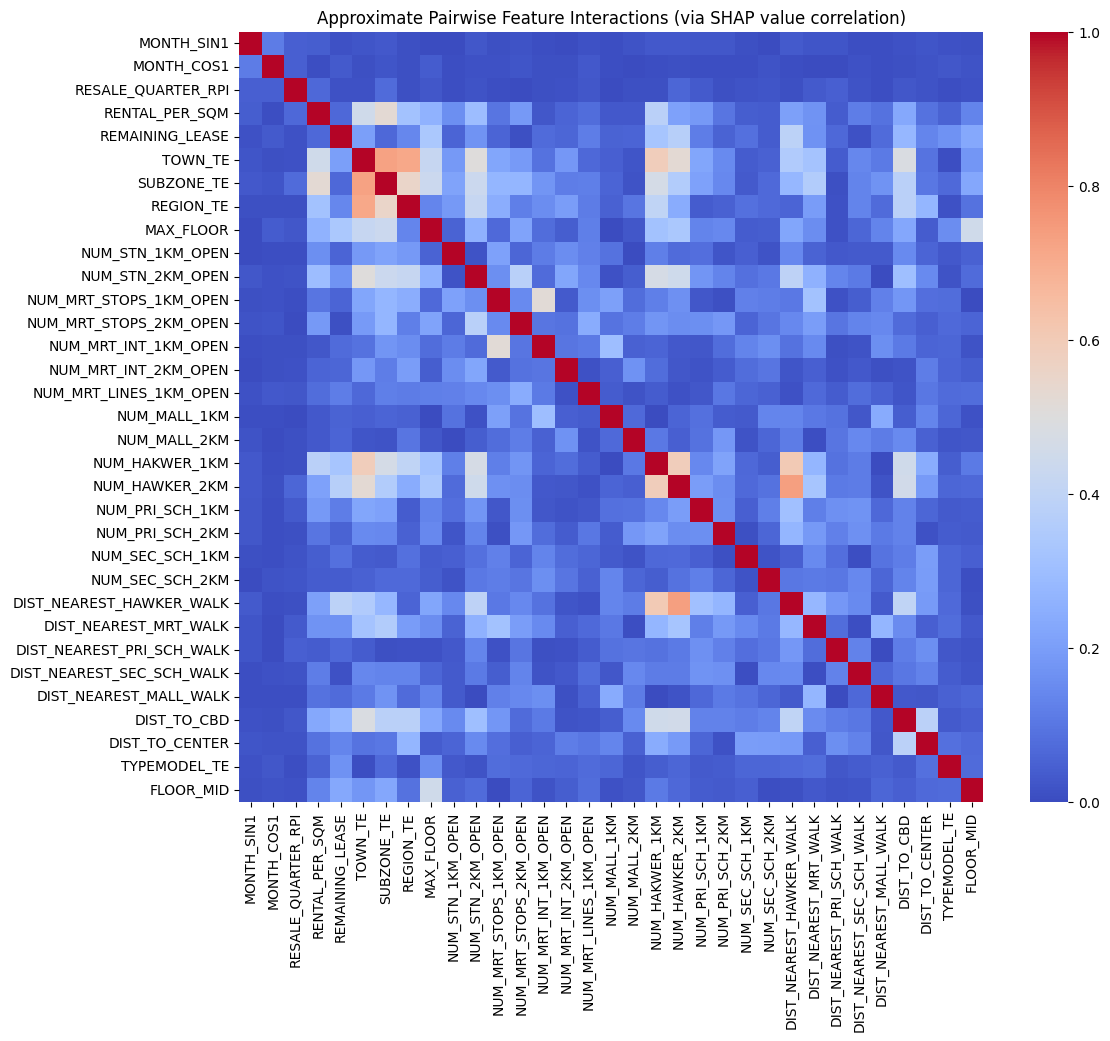

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(interaction_matrix, cmap="coolwarm", annot=False)
plt.title("Approximate Pairwise Feature Interactions (via SHAP value correlation)")
plt.show()


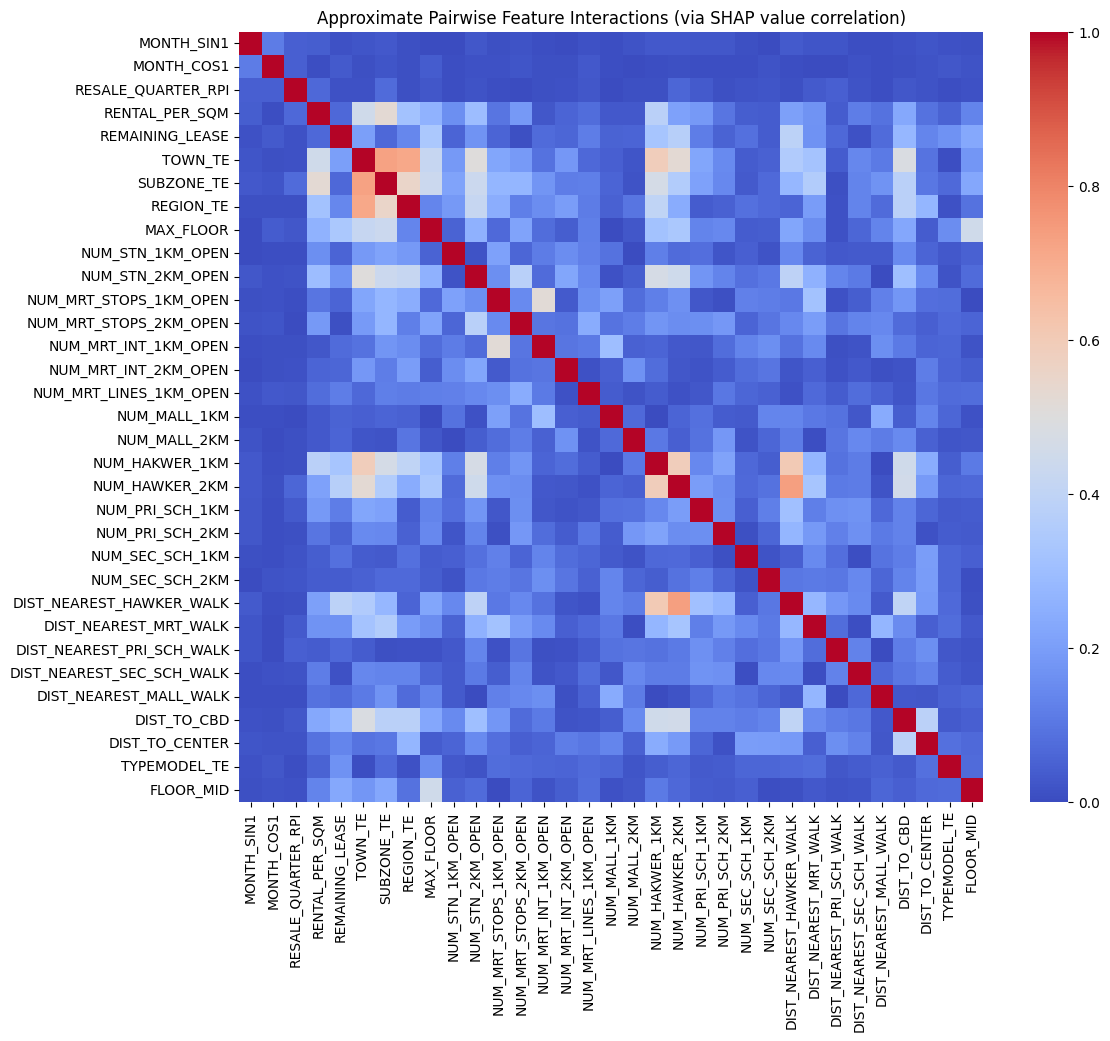

In [ ]:
# Save the heatmap
plt.figure(figsize=(12,10))
sns.heatmap(interaction_matrix, cmap="coolwarm", annot=False)
plt.title("Approximate Pairwise Feature Interactions (via SHAP value correlation)")
plt.savefig('shap_interaction_heatmap.png') # Saves the figure to a file
plt.show() # Display the plot after saving

# Save the interaction matrix as a CSV file
interaction_matrix.to_csv('shap_interaction_matrix.csv')